In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [20]:
from scipy.interpolate import lagrange, interp1d

In [13]:
x = np.linspace(0, 2*np.pi, 10)

In [14]:
y = np.sin(x)

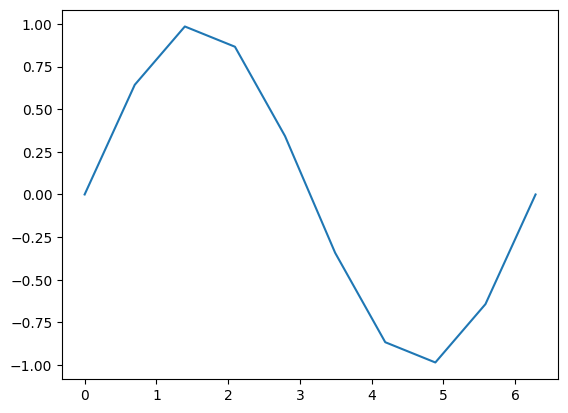

In [15]:
plt.plot(x, y)

In [16]:
X = np.linspace(0, 2*np.pi, 40)

In [22]:
f = interp1d(x, y)

In [23]:
Y = f(X)

In [24]:
Y

array([ 0.00000000e+00,  1.48335602e-01,  2.96671204e-01,  4.45006807e-01,
        5.93342409e-01,  6.95406093e-01,  7.74333819e-01,  8.53261544e-01,
        9.32189269e-01,  9.75670649e-01,  9.48259338e-01,  9.20848027e-01,
        8.93436715e-01,  8.66025404e-01,  7.45101113e-01,  6.24176822e-01,
        5.03252531e-01,  3.82328240e-01,  2.36783176e-01,  7.89277254e-02,
       -7.89277254e-02, -2.36783176e-01, -3.82328240e-01, -5.03252531e-01,
       -6.24176822e-01, -7.45101113e-01, -8.66025404e-01, -8.93436715e-01,
       -9.20848027e-01, -9.48259338e-01, -9.75670649e-01, -9.32189269e-01,
       -8.53261544e-01, -7.74333819e-01, -6.95406093e-01, -5.93342409e-01,
       -4.45006807e-01, -2.96671204e-01, -1.48335602e-01, -2.44929360e-16])

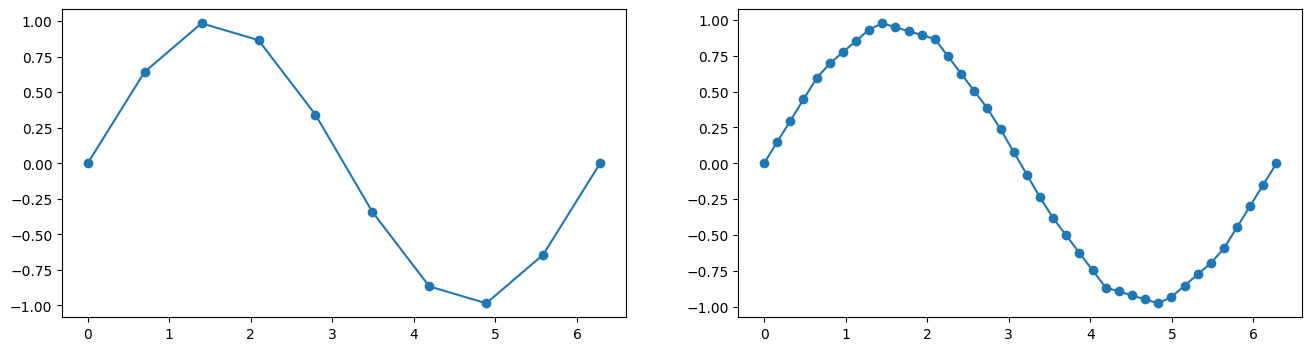

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,4))
ax1.plot(x, y, marker='o')
ax2.plot(X, Y, marker='o')

In [30]:
import pandas as pd

In [76]:
sale = pd.read_excel('./datas/catering_sale.xls')

In [77]:
sale.iloc[19:]

,日期,销量
19,2015-02-09,2173.5
20,2015-02-08,3161.8
21,2015-02-07,3023.8
22,2015-02-06,2998.1
23,2015-02-05,2805.9
...,...,...
196,2014-08-06,2915.8
197,2014-08-05,2618.1
198,2014-08-04,2993.0
199,2014-08-03,3436.4


In [78]:
sale['销量'][(sale['销量'] <400) | (sale['销量'] > 6000)] = None

C:\Users\litian\AppData\Local\Temp\ipykernel_13104\2314965014.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  sale['销量'][(sale['销量'] <400) | (sale['销量'] > 6000)] = None
C:\Users\litian\AppData\Local\Temp\ipykernel_13104\2314965014.py:1: 

In [79]:
sale

,日期,销量
0,2015-03-01,NaN
1,2015-02-28,2618.2
2,2015-02-27,2608.4
3,2015-02-26,2651.9
4,2015-02-25,3442.1
...,...,...
196,2014-08-06,2915.8
197,2014-08-05,2618.1
198,2014-08-04,2993.0
199,2014-08-03,3436.4


In [82]:
def fill_lagrange(s, n, k=5):
    y = s[list(range(n-k, n)) + list(range(n+1, n+1+k))]
    y = y[y.notnull()]
    return lagrange(y.index, list(y))(n)

In [83]:
for i in sale.columns:
    for j in range(sale[i].size):
        print(sale[i].isnull()[j])
        if sale[i].isnull()[j]:
            sale[i][j] = fill_lagrange(sale[i], j)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
Fals

C:\Users\litian\AppData\Local\Temp\ipykernel_13104\551449347.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sale[i][j] = fill_lagrange(sale[i], j)
C:\Users\litian\AppData\Local\Temp\ipykernel_13104\551449347.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sale[i][j] = fill_lagrange(sale[i], j)
C:\Users\litian\AppData\Local\Temp\ipykernel_13104\551449347.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sale[i][j] = fill_lagr

In [ ]:
fill_lagrange(sale['销量'], 8)

8148.300000002142